# Investigating parameters effects on Sensitivity of the OGGM Mass Balance and Runoff Models

In this notebook we will explore the sensitivity of OGGM's mass-balance and runoff models using SAFE. We will focus on the three parameters: melt factor, precipitation factor and temperature bias.

We will start by applying one-at-a-time sensitivity analysis to get a feel for how much each parameter affects the model and output. We will then consider the uncertainty of these sensitivities and work to quantify them.

## Sensitivity Analysis with the OGGM Mass Balance Model

We will apply sensitivity analysis in the following order to investigate our model behaviour:

1. **One-at-a-time**: We will apply one-at-a-time analysis , in which we change one parameter at a time and see how the mass balance changes in accordance. To show this, we will plot an interactive mass balance time series with toggles, where the parameter values can be changed within their default boundaries.
2. **Global sensitivity analysis**: Here we will use AAT sampling to randomly sample a combination of the 3 parameters and investigate the sensitivity in the following ways
    a. Qualitative - scatter plots
    b. Quantitative - RSA and bootstrapping

This will be applied first to the mass balance model in the OGGM, and then to the runoff model in the OGGM.

First we install the packages we require from both OGGM and SAFE.

In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import scipy.stats as st

import oggm
from oggm import cfg, utils, workflow
from oggm.core import massbalance
from oggm.utils._funcs import rmsd
from oggm import tasks
import multiprocessing as mp

# Install python package for interactive visualisation and import required functions:
%pip install -q ipywidgets
from ipywidgets import interact, fixed

# Install SAFE package and import required functions
%pip install SAFEpython

import xarray as xr
import safepython.PAWN as PAWN # Module to calculate PAWN sensitivity indices
import safepython.RSA_thres as RSA_tr # Module that implements RSA
from safepython.model_execution import model_execution # Module to execute the model
from safepython.sampling import AAT_sampling # Functions to perform the input sampling
from safepython.util import aggregate_boot # Functions to perform bootstrapping


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Now prepare to load the glacier dierectories from the OGGM.

In [13]:
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-calib-ro', reset=True)
cfg.PARAMS['border'] = 10
cfg.PARAMS['store_model_geometry'] = True
# cfg.PARAMS['use_multiprocessing'] = False  # To speed up sensitivity analysis runs
# cfg.PARAMS['mp_processes'] = -1  # Use all available cores
# oggm.cfg.PARAMS['min_ice_thick_for_length'] = 1  # a glacier is when ice thicker than 1m
# mp.set_start_method('spawn', force=True)

2026-02-04 16:25:56: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-02-04 16:25:56: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-02-04 16:25:56: oggm.cfg: Multiprocessing: using all available processors (N=22)


2026-02-04 16:25:56: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2026-02-04 16:25:56: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.


We start from a well known glacier in the Austrian Alps, Hintereisferner. But you can choose any other glacier, e.g. from [this list](https://github.com/OGGM/oggm-sample-data/blob/master/wgms/rgi_wgms_links_20220112.csv)

In [14]:
# Hintereisferner
rgi_id = 'RGI60-11.00897'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

2026-02-04 16:25:59: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2026-02-04 16:25:59: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


In [15]:
# # Get the observed mass balance and set up dataframe
# mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF
# mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE'] # In-situ mass balance for comparison

mbdf = gdir_hef.get_ref_mb_data().loc[1979:2019] # WGMS data for HEF
mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[1979:2019]['ANNUAL_BALANCE'] # In-situ mass balance for comparison


# 1 - One-at-a-time Sensitivity Analysis

We have loaded all required packages, so now we need to create a runner for the OGGM. To do this, we will set the 3 mass balance parameters to some tentative values, run the model and plot the resulting runoff timeseries. We can then change the parameter values one-at-a-time and look at how this changes the model predictions.

Since we have WGMS observed data here, we will use some fit-to-data metrics to compare the difference in mean, standard deviation and RMSD between the simulated and observed mass balance values.

In [17]:
import multiprocessing as mp
from oggm_runner import oggm_sim

# Use fork for WSL/Linux (faster, avoids spawn pickling issues)
mp.set_start_method("fork", force=True)

gdir = gdir_hef
years = range(1979,2020)

X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)

distr_fun = st.uniform # Uniform distribution for all parameters
x_min = np.array([1.5, 0.1, -2.0]) # Minimum values for each parameter
x_max = np.array([17.0, 10.0, 2.0]) # Maximum values for each parameter

distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
    
samp_strat = 'lhs' 

N = 12  # Number of samples
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Generate the samples


def run_sample(params):
    melt_f, prcp_fac, temp_bias = params
    return params, oggm_sim(gdir, melt_f, prcp_fac, temp_bias, years, run_with_hydro=True)

if __name__ == "__main__":
    with mp.Pool(processes=4) as pool:
        results = list(pool.map(run_sample, X))

results  # list of ((melt_f, prcp_fac, temp_bias), (mod_mb, runoff))

2026-02-04 16:26:22: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-02-04 16:26:22: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-02-04 16:26:22: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-02-04 16:26:22: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-02-04 16:26:22: oggm.cfg: Multiprocessing: using all available processors (N=22)
2026-02-04 16:26:22: oggm.cfg: Multiprocessing: using all available processors (N=22)
2026-02-04 16:26:22: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-02-04 16:26:22: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-02-04 16:26:22: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-02-04 16:26:22: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-02-04 16:26:22: oggm.cfg: Multi

ParserError: while parsing a block mapping
  in "/tmp/OGGM/OGGM-calib-ro/per_glacier/RGI60-11/RGI60-11.00/RGI60-11.00897/settings.yml", line 1, column 1
expected <block end>, but found ':'
  in "/tmp/OGGM/OGGM-calib-ro/per_glacier/RGI60-11/RGI60-11.00/RGI60-11.00897/settings.yml", line 2, column 1

In [ ]:
# from oggm.core import massbalance
# from oggm.core.massbalance import MultipleFlowlineMassBalance
# from oggm.core.flowline import run_with_hydro, FileModel
# from oggm import cfg, tasks, workflow
# import xarray as xr
# import numpy as np

# def oggm_sim(sample_row, gdir, run_with_hydro_flag=True, years=range(1979, 2020)):
#     """
#     Runs OGGM with sampled MB parameters and returns:
#       - Specific mass-balance time series (1979–2020)
#       - Runoff time series (1979–2020) if run_with_hydro_flag=True

#     Dynamic spin-up is used to reconstruct pre-RGI geometry. The hydrology
#     run *starts in 1979* from the *1979 geometry extracted from spin-up*,
#     which removes the early-year shock.
#     """

#     # --- 0) Reference MB index for reporting (optional) ---
#     mbdf = gdir.get_ref_mb_data().loc[years]

#     # --- 1) Parameters from sample ---
#     melt_f, prcp_fac, temp_bias = sample_row
#     melt_f = float(melt_f)
#     prcp_fac = float(prcp_fac)
#     temp_bias = float(temp_bias)

#     cfg.PARAMS['melt_f'] = melt_f
#     cfg.PARAMS['prcp_fac'] = prcp_fac
#     cfg.PARAMS['temp_bias'] = temp_bias
#     cfg.PARAMS['evolution_model'] = 'FluxBased'
#     cfg.PARAMS['store_model_geometry'] = True

#     # 2) The MB model for the historical run
#     mb_hist = MultipleFlowlineMassBalance(
#         gdir,
#         mb_model_class=massbalance.MonthlyTIModel,
#         melt_f=melt_f,
#         prcp_fac=prcp_fac,
#         temp_bias=temp_bias,
#         check_calib_params=False,
#     )

#     # Simple diagnostic MB (not required for hydro)
#     fls = gdir.read_pickle('inversion_flowlines')
#     mbdf['mod_mb'] = mb_hist.get_specific_mb(fls=fls, year=mbdf.index)

#     if not run_with_hydro_flag:
#         return np.array(mbdf['mod_mb']), None

#     # 3) Dynamic spin-up (short, stable window; store full evolution)
#     spinup_suffix = "_spinup"
#     rgi_plus1 = gdir.rgi_date + 1  # your target_yr (you reported 2004)
#     have_spinup = False
#     init_fls = None
#     init_yr = None

#     try:
#         # Let OGGM create its own spin-up MB model internally (do NOT pass mb_model_spinup)
#         workflow.execute_entity_task(
#             tasks.run_dynamic_spinup, [gdir],
#             mb_model_historical=mb_hist,
#             minimise_for='area',

#             spinup_start_yr=1979,
#             min_spinup_period=10,

#             # stabilise optimiser:
#             precision_percent=3,
#             first_guess_t_spinup=-3,
#             t_spinup_max_step_length=1,
#             maxiter=40,

#             # store full spin-up evolution up to target year:
#             ye=rgi_plus1,
#             store_model_evolution=True,
#             add_fixed_geometry_spinup=False,      # we want pure dynamic spin-up here
#             output_filesuffix=spinup_suffix,
#         )

#         # Extract the 1979 geometry from spin-up:
#         fspin = FileModel(gdir.get_filepath('model_geometry', filesuffix=spinup_suffix))
#         init_yr = 1979
#         fspin.run_until(init_yr)      # position the file-model at 1979
#         init_fls = fspin.fls          # flowlines at 1979
#         have_spinup = True

#     except Exception as e:
#         print(f"[spin-up fallback] Dynamic spin-up failed for this sample: {e}")
#         have_spinup = False

#     # 4) Hydrological run starting at 1979 with the 1979 geometry
#     file_id = f"_hydro_mf{melt_f:.2f}_pf{prcp_fac:.2f}_tb{temp_bias:.2f}"

#     kwargs_hydro = dict(
#         run_task=tasks.run_from_climate_data,
#         ys=1979, # we hydro from 1979
#         min_ys=1979, # allow early evaluation (doc)
#         mb_model=mb_hist,
#         store_monthly_hydro=True,
#         output_filesuffix=file_id,
#     )

#     if have_spinup and (init_fls is not None):
#         # Start from *1979* spin-up geometry (no fixed-geometry padding)
#         kwargs_hydro.update(dict(init_model_fls=init_fls, init_model_yr=init_yr))
#     else:
#         # Fallback: fixed-geometry pre-RGI padding for early years
#         kwargs_hydro.update(dict(fixed_geometry_spinup_yr=1979))

#     workflow.execute_entity_task(tasks.run_with_hydro, [gdir], **kwargs_hydro)

#     # 5) Read hydro output
#     with xr.open_dataset(gdir.get_filepath('model_diagnostics', filesuffix=file_id)) as ds:
#         ds = ds.isel(time=slice(0, -1)).load()

#     runoff_vars = ['melt_off_glacier', 'melt_on_glacier',
#                    'liq_prcp_off_glacier', 'liq_prcp_on_glacier']
#     df_annual = ds[runoff_vars].to_dataframe().clip(0)
#     runoff = (df_annual * 1e-9).sum(axis=1).to_numpy()  # kg -> Mt

#     return np.array(mbdf['mod_mb']), runoff

In [ ]:
# from oggm.core.massbalance import MultipleFlowlineMassBalance

# def oggm_sim(sample_row, gdir, run_with_hydro=True, years=range(1979,2020)): # TODO: Add in the full workflow to ensure that the model runs correctly - with the new parameters
#     '''
#     Reads in the parameters (melt_f, prcp_fac and temp_bias) set in the inputs, and runs the OGGM processes to 
#     produce either a time series for the annual specific mass balance, or for the annual runoff.

#     Parameters:
#     -------------
#     sample_row: Tuple
#         The parameters we are feeding in (likely from our randomly generated samples). This is a tuple of
#         (melt_f, prcp_fac, temp_bias).
#     gdir: GlacierDirectory
#         The glacier directory.
#     run_with_hydro=False: bool
#         A flag to indicate if the user wishes to produce a regular mass balance timeseries, or requires to execute the
#         OGGM task, run_with_hydro, which produces a timeseries of the runoff.
#     years: range(int,int)
#         The years we wish to produce a timeseries for.

#     Returns:
#     -------------
#     np.ndarray
#         Specific mass balance (units: mm w.e. yr-1).
#         OR Runoff (units: Mt w.e. yr-1).

#     '''

#     mbdf = gdir.get_ref_mb_data().loc[years] # WGMS data for HEF
    
#     # Set the parameter values
#     melt_f, prcp_fac, temp_bias = sample_row
#     cfg.PARAMS['melt_f'] = float(melt_f)
#     cfg.PARAMS['prcp_fac'] = float(prcp_fac)
#     cfg.PARAMS['temp_bias'] = float(temp_bias)

    
#     gdir.settings['melt_f'] = float(melt_f)
#     gdir.settings['prcp_fac'] = float(prcp_fac)
#     gdir.settings['temp_bias'] = float(temp_bias)

#     # Hydrological model workflow steps before running with hydro
#     cfg.PARAMS['evolution_model'] = 'FluxBased'
#     cfg.PARAMS['store_model_geometry'] = True
    
#     # Convert the flowlines to a "glacier" for the ice dynamics module
#     workflow.execute_entity_task(tasks.init_present_time_glacier, [gdir])

#     mb = MultipleFlowlineMassBalance(
#         gdir,
#         mb_model_class=massbalance.MonthlyTIModel,
#         melt_f=melt_f,
#         prcp_fac=prcp_fac,
#         temp_bias=temp_bias,
#         check_calib_params=False,
#         )
    
#     fls = gdir.read_pickle('inversion_flowlines') # Read flowlines
#     mbdf['mod_mb'] = mb.get_specific_mb(fls=fls, year=mbdf.index) # Compute modelled mass balance  

#     if not run_with_hydro: # If the run_with_hydro flag is set to false, just return the mass balance
#         return np.array(mbdf['mod_mb'])

#     else: # If the run_with_hydro flag is set to true, generate the hydrological data and calculate the runoff
#         gdir.settings['error_when_glacier_reaches_boundaries'] = False # TODO- When more realistic, I assume we will not need this?

#         # file identifier where the model output is saved
#         # Create unique file identifier based on parameters
#         file_id = f'_hydro_mf{melt_f:.2f}_pf{prcp_fac:.2f}_tb{temp_bias:.2f}'

#         cfg.PARAMS['store_model_geometry'] = True  # add additional outputs for the maps below
#         cfg.PARAMS['evolution_model'] = 'FluxBased'

#         workflow.execute_entity_task(
#             tasks.run_with_hydro,
#             [gdir],
#             run_task=tasks.run_from_climate_data,
#             ys=years[0],
#             mb_model=mb,
#             store_monthly_hydro=True,
#             output_filesuffix=file_id,
#         )
    
#         with xr.open_dataset(gdir.get_filepath('model_diagnostics', filesuffix=file_id)) as ds:
#             # The last step of hydrological output is NaN (we can't compute it for this year)
#             ds = ds.isel(time=slice(0, -1)).load()
            
#         # These summed variabels give the total runoff from the glacier
#         runoff_vars = ['melt_off_glacier', 'melt_on_glacier','liq_prcp_off_glacier', 'liq_prcp_on_glacier']

#         df_annual = ds[runoff_vars].to_dataframe()
#         df_runoff = df_annual[runoff_vars].clip(0) * 1e-9

#         # # Convert them to megatonnes (instead of kg)
#         runoff = df_runoff.sum(axis=1).to_numpy()
#         return runoff

In [36]:
def fit_to_data_metric_calculator(sim, gdir, years=range(1979,2020)):
    '''
    Calculates the fit-to-data metrics from the Mass Balance data, on which we can run the sensitivity analysis.
    This is only used for the mass balance, where we can access a sufficient amount of data to calculate these metrics.

    Parameters:
    ------------

    sim: np.array
        The mass balance time series generated from the oggm_sim method, when the output is the mass balance time series.

    gdir: GlacierDirectory
        The glacier directory.

    years: range(int,int)
        The years we are using data from.

    Return:
    ------------

    YY: np.array
        An array containing the values of:
            - The difference in mass balance between the observed and simulated means.
            - The difference in mass balance between the observed and simulated standard deviations.
            - The RMSD between the simulated mass balance and the observed mass balance annual values.
    '''
    
    # Get the observed mass balance and set up dataframe
    mbdf = gdir.get_ref_mb_data().loc[years] # WGMS data for HEF
    mbdf['in_situ_mb'] = gdir.get_ref_mb_data().loc[years]['ANNUAL_BALANCE'] # In-situ mass balance for comparison

    # Calculates the goodness-of-fit metrics for all model simulations compared to the in-situ mass balance
    YY = np.zeros((sim.shape[0], 3))

    for i in range(sim.shape[0]):
        # Calculate the goodness-of-fit metrics from the simulated mass balance and the in-situ mass balance
        YY[i, 0] = np.array(sim[i].mean() - mbdf['in_situ_mb'].mean()) # Calculate mean difference
        YY[i, 1] = np.array(sim[i].std() - mbdf['in_situ_mb'].std()) # Calculate standard deviation difference
        YY[i, 2] = np.array(rmsd(sim[i], mbdf['in_situ_mb'])) # Calculate RMSD

    return YY

In [37]:
def hydro_output_metric_calculator(runoff):
    '''
    Calculates the output metrics for runoff, the mean and the standard deviation. 

    This is currently only used for calculting the mean and standard deviation of the runoff
    but can be added to in the future.

    Parameters:
    ------------

    runoff: np.array
        The runoff time series generated from the oggm_sim method, when the output is the runoff time series.

    Return:
    ------------

    YY: np.array
        An array containing the values of:
            - The annual runoff mean.
            - The annual runoff standard deviation.
    '''
    YY = np.nan * np.ones((len(runoff), 2))

    for i, x in enumerate(runoff):
        YY[i,0] = np.mean(x)
        YY[i,1] = np.std(x)

    return YY

We will now plot our results, the parameter values can be changed one-at-a-time via a toggle on the graph below.

In [ ]:
# Define interactive visualisation function to set the parameters to some tentative values, 
# run the model and plot the resulting runoff time series
def oat_function(gdir, years, melt_f = 5.0, prcp_fac = 3.4, temp_bias = 0.0):
    '''  
    Calls the oggm_sim function and plots each mass balance time series with an interactive plot.

    Parameters:
    ------------
    gdir: GlacierDirectory
        The glacier directory.
    years: range
        The years we are investigating.
    melt_f = 5.0: float
        The value of the melt factor you want to use, here the unit
        is kg m-2 day-1 K-1. Defaults to the default value.
    prcp_fac = 3.4: float
        The value of the precipitation factor. Defaults to the
        default value.
    temp_bias : float
        The value of the temperature bias. Defaults to the
        default value.


    Returns:
    ------------
    An interactive plot displaying the mass balance time series of the glacier with the given parameters.
    '''
    # Create parameter array
    param = np.array([melt_f, prcp_fac, temp_bias])
    
    # Get the observed mass balance and set up dataframe
    mbdf = gdir.get_ref_mb_data().loc[years] # WGMS data for HEF
    mbdf['in_situ_mb'] = gdir.get_ref_mb_data().loc[years]['ANNUAL_BALANCE'] # In-situ mass balance for comparison

    # Run the model with the given parameters, here we are interested in the modelled mass balance time series
    mb, runoff = oggm_sim(param, gdir, run_with_hydro=False, years=years)

    # Plot the results
    plt.figure(figsize=[15,3])
    plt.plot(mbdf['in_situ_mb'].index, mb, label='sim', color='k')
    mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[years]['ANNUAL_BALANCE']
    plt.plot(mbdf['in_situ_mb'], color=[0.7,0.7,0.7], label='obs')
    plt.ylabel('Specific mass balance (mm w.e.)')
    plt.xlabel('Year')
    plt.legend()
    plt.show();

# Create interactive plot, the toggles will change the parameter values 
interact(oat_function,
         gdir = fixed(gdir_hef),
         run_with_hydro = fixed(False),
         years = fixed(range(1979,2020)),
         melt_f = (1.5, 17.0, 0.1),
         prcp_fac = (0.1, 10.0, 0.1),
         temp_bias = (-15.0, 15.0, 0.1));

interactive(children=(FloatSlider(value=5.0, description='melt_f', max=17.0, min=1.5), FloatSlider(value=3.4, …

The above graph shows the effects that moving each of the parameters has to the mass balance time series.

# GSA - Global Sensitvity Analysis

For our Global Sensitivity Analysis here we will be initially using Regional Sensitivity Analysis (RSA) and exploring PAWN in the SAFE Toolbox later on. More information on the RSA method can be seen in [Pianosi et al., 2016](https://www.sciencedirect.com/science/article/pii/S1364815216300287?fr=RR-2&ref=pdf_download&rr=9c07930109fe6535#bib67).

RSA is also called Monte Carlo filtering, here we split input samples depending on whether the associated output is above or below a prescribed threshold. Then the two input sets are compared to gain insight on the model behaviour and mapping.

RSA has been widely used in applications where the model output is an objective function (i.e. a measure of the model accuracy against observations) and splitting the criterion reflects the acheivement of a minimum requirement of model performance. This works well for our Mass-Balance sensitivity in the OGGM since we have access to WGMS data from observations of the Mass-Balance. We will be comparing the fit-to-data metrics of: the difference in mean values, the difference in standard deviation values and the RMSD. In an ideal scenario, we will be aiming to get this as close to 0 as possible and so we can use this as our RSA threshold. 

We will be using AAT Sampling from SAFE to perform global sampling. This method will be creating Monte Carlo Simulations, we will start by plotting the mass balance time series resulting from the Monte Carlo simulations and analyse the results.

### Running Monte Carlo Simulations

In [39]:
X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)

distr_fun = st.uniform # Uniform distribution for all parameters
x_min = np.array([1.5, 0.1, -2.0]) # Minimum values for each parameter
x_max = np.array([17.0, 10.0, 2.0]) # Maximum values for each parameter

distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
    
samp_strat = 'lhs' 

N = 1000  # Number of samples
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Generate the samples

sim = model_execution(oggm_sim, X, gdir_hef, False) # Execute the model for all samples

2026-02-04 11:45:03: oggm.cfg: PARAMS['melt_f'] changed from `5.0` to `10.469642837099151`.
2026-02-04 11:45:03: oggm.cfg: PARAMS['prcp_fac'] changed from `3.400000000000001` to `8.532674825177702`.
2026-02-04 11:45:03: oggm.cfg: PARAMS['temp_bias'] changed from `0.0` to `-0.10331433801610324`.


2026-02-04 11:45:03: oggm.cfg: PARAMS['melt_f'] changed from `10.469642837099151` to `2.626213352734344`.
2026-02-04 11:45:03: oggm.cfg: PARAMS['prcp_fac'] changed from `8.532674825177702` to `5.414049133246514`.
2026-02-04 11:45:03: oggm.cfg: PARAMS['temp_bias'] changed from `-0.10331433801610324` to `0.40738957138010967`.
2026-02-04 11:45:03: oggm.cfg: PARAMS['melt_f'] changed from `2.626213352734344` to `7.17828556226212`.
2026-02-04 11:45:03: oggm.cfg: PARAMS['prcp_fac'] changed from `5.414049133246514` to `9.640123980845283`.
2026-02-04 11:45:03: oggm.cfg: PARAMS['temp_bias'] changed from `0.40738957138010967` to `-0.19578863527188828`.
2026-02-04 11:45:03: oggm.cfg: PARAMS['melt_f'] changed from `7.17828556226212` to `15.571767791873755`.
2026-02-04 11:45:03: oggm.cfg: PARAMS['prcp_fac'] changed from `9.640123980845283` to `8.288367841549515`.
2026-02-04 11:45:03: oggm.cfg: PARAMS['temp_bias'] changed from `-0.19578863527188828` to `1.369663241829827`.
2026-02-04 11:45:03: oggm.c

In [40]:
# TODO - investigate the relationship between mean and RMSD
# investigate with this part here - the RMSD and its decomposition
import numpy as np
import pandas as pd

x = np.asarray(sim[0])
y = np.asarray(mbdf['in_situ_mb'])

rmse = np.sqrt(np.mean((x - y)**2)) # Coded calculation of the RMSD that we would expect
rmsd_test = rmsd(x,y)
bias = np.mean(x - y)

# Stats
sx = np.std(x, ddof=1)
sy = np.std(y, ddof=1)
r  = np.corrcoef(x, y)[0,1]

# Decomposition pieces
variance_term = sx**2 + sy**2 - 2*sx*sy*r
lhs = rmse**2
rhs = bias**2 + variance_term

print(f"RMSE: {rmse:.6f}")
print(f"RMSD: {rmsd_test:.6f}")
print(f"|Bias|: {abs(bias):.6f}")
print(f"sx, sy, r: {sx:.6f}, {sy:.6f}, {r:.6f}")
print(f"RMSE^2 vs bias^2 + variance term: {lhs:.6f} vs {rhs:.6f}")

# The bias is the largest contributor to the RMSD in this case, indicating that the model systematically
# over or underestimates the mass balance compared to observations. Therefore leading to the linear relationship between the mean and the RMSD.


RMSE: 3551.599616
RMSD: 3551.599616
|Bias|: 3309.357705
sx, sy, r: 1651.789411, 525.141601, 0.749703
RMSE^2 vs bias^2 + variance term: 12613859.830531 vs 12655410.115721


In [41]:
YY = fit_to_data_metric_calculator(sim, gdir_hef) # Calculate the output metrics for all simulations

Plotting the Monte Carlo simulation results and comparison with the observed data.

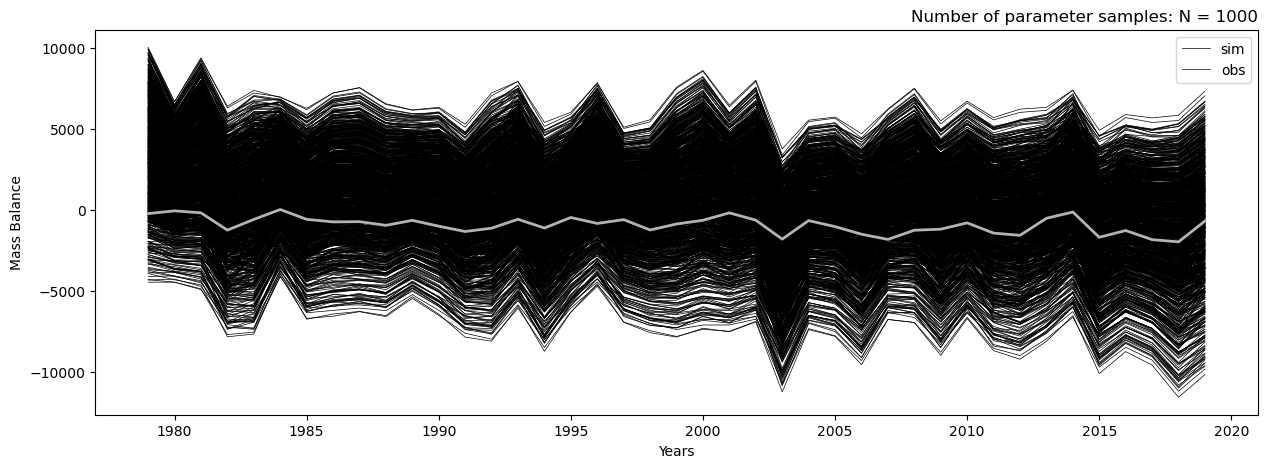

In [28]:
# Plot Monte Carlo (MC) simulations results and compare with data:
plt.figure(figsize=[15,5])
plt.plot(mbdf['in_situ_mb'].index.values, np.transpose(sim), 'k', linewidth = 0.5)
plt.plot(mbdf['in_situ_mb'], color=[0.7,0.7,0.7], linewidth=2)
plt.ylabel('Mass Balance'); plt.xlabel('Years')
plt.legend(['sim', 'obs'])
plt.title("Number of parameter samples: N = %d" % N, loc='right')
plt.show()

We can see from the samples that the mass balance is greatly affected by altering the parameters between their given ranges. The lower mass balances seem to be more sparse, with a more significant clustering towards the higher mass-balances. The observed mass-balance is closer towards the higher mass-balance end of the spectrum, towards 0. 

### Scatter plot of the fit-to-data metrics

We will now plot a scatter plot of the fit-to-data metrics, this will show us the relationship between the metrics created from our Monte Carlo simulations.

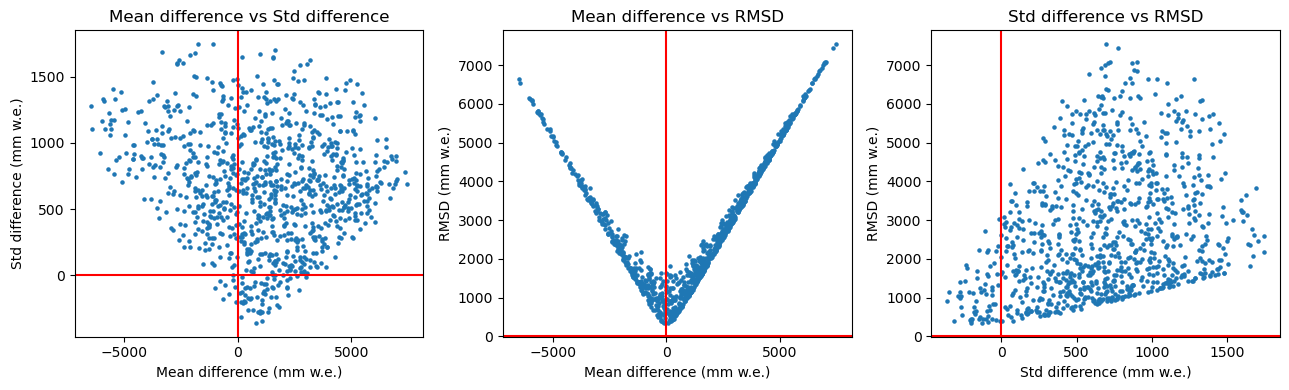

In [29]:
plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.scatter(YY[:,0], YY[:,1], s=5), plt.title('Mean difference vs Std difference'), plt.xlabel('Mean difference (mm w.e.)'), plt.ylabel('Std difference (mm w.e.)'),
plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')
plt.gca().locator_params(axis='x', nbins=6)

plt.subplot(1,3,2), plt.scatter(YY[:,0], YY[:,2], s=5), plt.title('Mean difference vs RMSD'), plt.xlabel('Mean difference (mm w.e.)'), plt.ylabel('RMSD (mm w.e.)')
plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')
plt.gca().locator_params(axis='x', nbins=6)

plt.subplot(1,3,3), plt.scatter(YY[:,1], YY[:,2], s=5), plt.title('Std difference vs RMSD'), plt.xlabel('Std difference (mm w.e.)'), plt.ylabel('RMSD (mm w.e.)')
plt.axvline(x=0, color='r'), plt.axhline(y=0, color='r')
plt.gca().locator_params(axis='x', nbins=6)

plt.tight_layout()
plt.show()

# The red lines show the target of having zero differences in the mean, standard deviation and RMSD.
# TODO: Would absolute differences be better than the raw ones?

The red lines show the target values of our differences, ideally we would want our differences to be 0 and to match the observations as closely as possible.

It can be seen here that all of our fit-to-data metrics are correlated.

## Scatter plot for the parameters against the fit-to-data metrics

Now we can plot the scatter plots for each parameter against each metric, this will help visualise the sensitivities for the mass balance.

In [30]:
YY_Labels = ['Mean Difference', 'Std Difference', 'RMSD']

def scatter_function(metric='Mean Difference'):
    if metric == 'Mean Difference':
        j = 0
    elif metric == 'Std Difference':
        j = 1  
    elif metric == 'RMSD':
        j = 2
    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        plt.plot(X[:, i], YY[:,j], '.', markerfacecolor="white", markeredgecolor="grey")        
        if i == 0:
            plt.ylabel(YY_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       
    plt.show()

interact(scatter_function,  metric = YY_Labels);

interactive(children=(Dropdown(description='metric', options=('Mean Difference', 'Std Difference', 'RMSD'), va…

### Distribution of the model outputs

Now looking at the distribution of the model outputs, here this is the goodness-of-fit parameters.

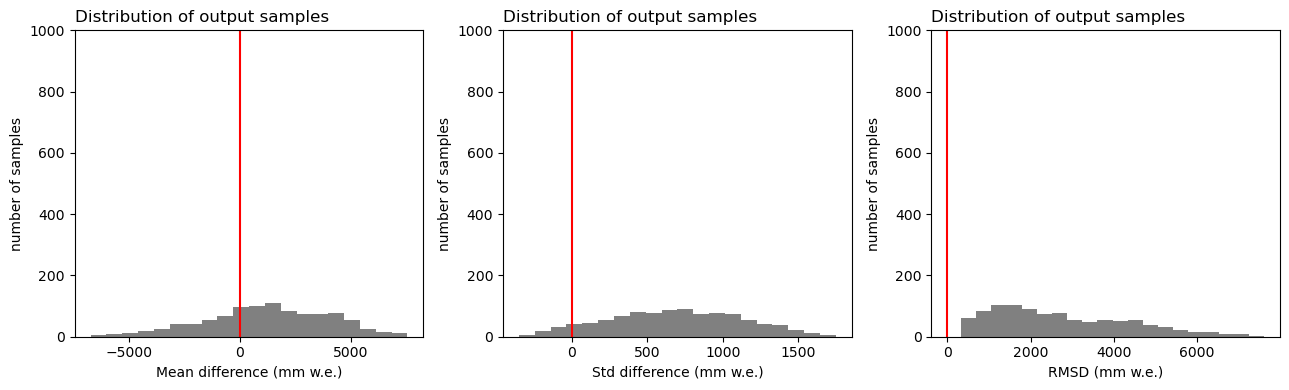

In [19]:
Y_Labels = ['Mean difference (mm w.e.)', 'Std difference (mm w.e.)', 'RMSD (mm w.e.)', 'Mean & Std difference jointly']

plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.title('Distribution of output samples', loc='left'), plt.hist(YY[:,0], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_Labels[0])
plt.gca().locator_params(axis='x', nbins=6)

plt.subplot(1,3,2), plt.title('Distribution of output samples', loc='left'), plt.hist(YY[:,1], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_Labels[1])
plt.gca().locator_params(axis='x', nbins=6)

plt.subplot(1,3,3), plt.title('Distribution of output samples', loc='left'), plt.hist(YY[:,2], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_Labels[2])
plt.gca().locator_params(axis='x', nbins=6)

plt.tight_layout()

Looking at our distributions of the output samples, the distributions are as follows:
1. Mean difference: Skewed distribition with a long tail (negative skew)
2. Std difference: Normal distribution
3. RMSD: Skewed distribution with a long tail (positive skew)

# Calculating the Sensitivity Indices

Now we use the input-output samples generated in the previous step to calculate sensitivity indices using **Regional Sensitivity Analysis**. Calculating 3 sets of indices, each measuring the relative importance of the 3 input parameters.

Since we have some fit-to-data metrics, we know that ideally the differences between the simulated and observed means, standard deviation and the RMSD would be as close to 0 as possible. Therefore for a ranking of the sensitivites of our parameters against the outputs, we can set the threshold to be 0 (or as close to 0 as the dataset permits).

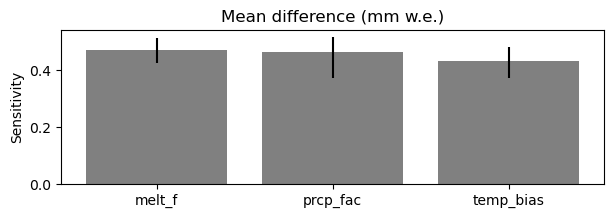

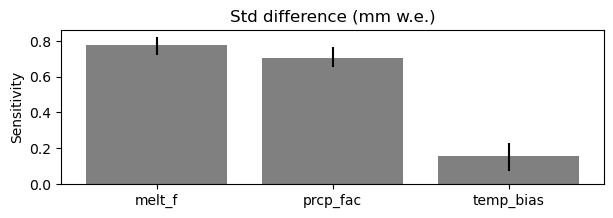

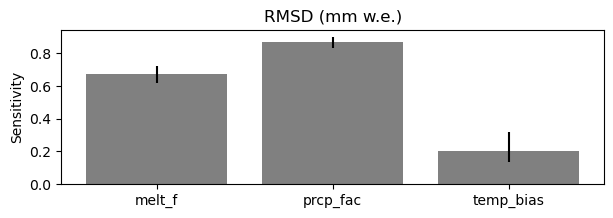

In [20]:
Nboot = 50 # Number of resamples used for bootstrapping

for i in range(3):
    if i==0:
        Y=YY[:,0]
        target=0
    if i==1:
        Y=YY[:,1]
        target=0
    if i==2:
        Y = YY[:,2]
        target = 500 # RMSD cannot be zero here? Minimum working number is around 550, minimum observed value is around 400.

    # Plotting the RSA sensitivity indices with bootstrapped error bars
    plt.figure(figsize=[7,2])
    mvd, _, _, idx = RSA_tr.RSA_indices_thres(X, Y, target, Nboot=Nboot)
    mvd_m, mvd_lb, mvd_ub = aggregate_boot(mvd) # shape (M,)
    yerr=np.c_[mvd_m-mvd_lb,mvd_ub-mvd_m].T
    plt.bar(range(len(mvd_m)), mvd_m, color='grey',yerr=yerr)
    plt.title(Y_Labels[i], loc='center'), plt.xticks(range(len(mvd_m)), X_labels), plt.ylabel('Sensitivity')
    plt.show()

Now lets discuss the outcome of our sensitivity analysis here with the three fit-to-data metrics:

1. For the first metric: The difference between the observed and the simulated mass balance mean values. The temperature bias is significantly the most impactful here. This would align with what we might expect, the temperature bias increases or decreases the temperature, which will have an impact on the amount of glacier mass we are either losing or retaining due to melting and whether or not the precipitation is liquid or solid. We are also currently using the OGGM's default range which is between -15 and +15 degrees celcius, this is a very large range and therefore this makes sense this is the most impactful for the differences between the mass balance means between the observed and simulated. The temperature bias will create a uniform shift in temperatures which will then shift the mean values.

2. For the second metric: The difference between the observed and simulated mass balance standard deviation values. The precipitation factor is the most significant in our study. The precipitation factor controls the amount of precipitation for the glacier, therefore controlling accumulation which strongly affects the variability of the mass balance.

3. Finally, for the third metric: The RMSD, this penalises larger differences and is dominated by larger deviations. The melt factor is the factor that controls how much ablation occurs, this melt will be amplified in high-melt periods and much lower at lower melt periods. Therefore this will affect the RMSD more, due to the large deviations the melt factor can cause throughout difference period of the year.

## Extra Investigation: Relationship with temp_bias and other parameters to the fit-to-data outputs

Now checking, if the relationship with other parameters has been affected by the temp_bias, this is rather dominant in the differences of the mean. We can plot a colour map to check.

In [21]:
temp_bias_index = 2  # Index of temp_bias in X

YY_Labels = ['Mean Difference', 'Std Difference', 'RMSD']

def scatter_function(metric='Mean Difference'):
    if metric == 'Mean Difference':
        j = 0
    elif metric == 'Std Difference':
        j = 1  
    elif metric == 'RMSD':
        j = 2

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        # Use scatter with color mapped to temp_bias
        sc = plt.scatter(X[:, i], YY[:, j], c=X[:, temp_bias_index], cmap='coolwarm', edgecolors='grey')
        
        if i == 0:
            plt.ylabel(YY_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       

        # Add colorbar only once
        if i == M-1:
            cbar = plt.colorbar(sc)
            cbar.set_label('Temp Bias (°C)')
    plt.show()

interact(scatter_function, metric=YY_Labels);


interactive(children=(Dropdown(description='metric', options=('Mean Difference', 'Std Difference', 'RMSD'), va…

# Hydrological Response Metrics - Performance Metrics

Now looking at the hydrological response metrics we have avaliable in the OGGM, mean of runoff and mean of volume.

## One-at-a-time Sensitivity Analysis

In [61]:
# Define interactive visualisation function to set the parameters to some tentative values, 
# run the model and plot the resulting runoff time series

def oat_hydro_function(gdir, melt_f = 5.0, prcp_fac = 3.4, temp_bias = 0.0):
    # Create parameter array
    param = np.array([melt_f, prcp_fac, temp_bias])
    
    # Run the model with the given parameters, here we are interested in the modelled mass balance time series
    runoff = oggm_sim(param, gdir) # Using the runoff output here instead of the mass balance
    # Plot the results
    plt.figure(figsize=[15,3])
    plt.plot(runoff, label='sim', color='k')
    plt.ylabel('Runoff (Mt)')
    plt.xlabel('Year')
    plt.legend()

# Create interactive plot, the toggles will change the parameter values 
interact(oat_hydro_function,
         gdir = fixed(workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]),
         melt_f = (1.5, 17.0, 0.1),
         prcp_fac = (0.1, 10.0, 0.1),
         temp_bias = (-15.0, 15.0, 0.1));

2026-02-03 10:55:37: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2026-02-03 10:55:37: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


interactive(children=(FloatSlider(value=5.0, description='melt_f', max=17.0, min=1.5), FloatSlider(value=3.4, …

# GSA - Global Sensitivity Analysis

Now applying RSA to our runoff data to perform a Sensitivity Analysis,
[Pianosi et al., 2016](https://www.sciencedirect.com/science/article/pii/S1364815216300287?fr=RR-2&ref=pdf_download&rr=9c07930109fe6535#bib67). As discussed with the Mass-Balance timeseries, the RSA typically requires a specified threshold. We currently do not have access to runoff data to provide a threshold and compare our simulated outputs. To work around this issue and apply RSA without specifying thresholds, we can group the ranked output samples into a prescribed number (e.g. 10) and compare the 10 resulting distribution functions of the input factors. (TODO: Is this built into SAFE?) This isn't avaliable in SAFE, so we will be attempting an alternative method which does not require a threshold, PAWN. Which is a novel density-based method.

We will however include the original SAFE implementation of RSA for consistency with the first method, and some arbitrary thresholds. If we do obtain the values of the observed mean runoff and standard deviation of runoff then we can easily change the code to implement the method correctly.

### Running Monte Carlo Simulations

In [62]:
X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)
distr_fun = st.uniform # Uniform distribution for all parameters
x_min = np.array([1.5, 0.1, -15.0]) # Minimum values for each parameter
x_max = np.array([17.0, 10.0, 15.0]) # Maximum values for each parameter

distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
samp_strat = 'lhs' 
N = 10 # Was 2000, TODO- change back to 2000? 1000 takes around 11 mins to run
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Generate the samples

When using the SAFE model_execution function, we can only return one timeseries. The other output is forced to be a scalar output per sample iteration. Here we wish to have two timeseries outputted so we will be updating the model_execution function to be able to output the extra timeseries.

In [127]:
import numpy as np
import warnings
from typing import Any, List, Tuple, Union

def model_execution_mo(
    fun_test,
    X: np.ndarray,
    *args: Any,
    ExtraArgOut: bool = False,
    NumberArgOut: int = 0,
) -> Any:
    """
    Executes the model coded in the matlab function `fun_test` against each sample input
    vector in matrix X, and returns the associated output vectors (in matrix Y).

    Parameters
    ----------
    Input:
     fun_test = function implementing the model.           - python function
                The first output argument of
                'fun_test' must be a numpy.ndarray of
                shape (P, ), (1,P) or (P,1).
           X = matrix of N input sample                    - numpy.ndarray(N,M)
              (each input sample has M components)

    Optional input:
     *args = extra arguments needed to execute 'fun_test'

     ExtraArgOut = specifies if extra output arguments must - boolean
                  be returned beyond Y in case
                  'fun_test' provides extra output
                  arguments.
                  (default: False, i.e. no extra output
                  arguments are returned)

     NumberArgOut = specifies how many outputs are to be outputted. - int

     
     Output:
        Y = matrix of N output sample                    - numpy.ndarray(N,P)
            (each output sample has P components)

    """
    
    ###########################################################################
    # Check inputs
    ###########################################################################
    if not isinstance(X, np.ndarray):
        raise ValueError('"X" must be a numpy.array.')
    if X.dtype.kind != 'f' and X.dtype.kind != 'i' and X.dtype.kind != 'u':
        raise ValueError('"X" must contain floats or integers.')
    Nx = X.shape
    N = Nx[0]
    if len(Nx) != 2:
        raise ValueError('"X" must have at least two rows.')
    if not isinstance(ExtraArgOut, bool):
        raise ValueError('"ExtraArgOut" must be scalar and boolean.')
    
    if (ExtraArgOut == False) and (NumberArgOut != 0):
        warnings.warn('"NumberArgOut" is ignored since "ExtraArgOut" is False.')
    
    Y = np.empty((N, NumberArgOut), dtype=object)
    # Y = np.nan * np.ones((N, NumberArgOut)) # variable initialization
    for j in range(N):
        out = fun_test(X[j, :], *args)
        for k in range(NumberArgOut):
            Y[j, k] = out[k]
    
    return Y

In [287]:
X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)

distr_fun = st.uniform # Uniform distribution for all parameters
x_min = np.array([1.5, 0.1, -2.0]) # Minimum values for each parameter
x_max = np.array([17.0, 10.0, 2.0]) # Maximum values for each parameter

distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
    
samp_strat = 'lhs' 

N = 20 # Number of samples
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Generate the samples

out  = model_execution_mo(oggm_sim, X, gdir_hef, True, ExtraArgOut=True, NumberArgOut=2) # Execute the model for all samples - note: takes around 5-10 mins with N=1000

2026-02-03 16:38:42: oggm.cfg: PARAMS['melt_f'] changed from `5.0` to `10.479052742646076`.
2026-02-03 16:38:42: oggm.cfg: PARAMS['temp_bias'] changed from `1.3313268630178605` to `1.809542690078962`.
2026-02-03 16:38:42: oggm.cfg: PARAMS['evolution_model'] changed from `SemiImplicit` to `FluxBased`.


2026-02-03 16:38:42: oggm.workflow: Execute entity tasks [run_dynamic_spinup] on 1 glaciers
2026-02-03 16:38:47: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-03 16:38:47: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-02-03 16:38:48: oggm.cfg: PARAMS['melt_f'] changed from `10.479052742646076` to `3.5152171424509726`.
2026-02-03 16:38:48: oggm.cfg: PARAMS['prcp_fac'] changed from `6.219237420568456` to `5.15820228961648`.
2026-02-03 16:38:48: oggm.cfg: PARAMS['temp_bias'] changed from `1.809542690078962` to `1.4082479433469333`.
2026-02-03 16:38:48: oggm.workflow: Execute entity tasks [run_dynamic_spinup] on 1 glaciers
2026-02-03 16:38:58: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-03 16:38:58: oggm.core.flowline: You are attempting to run_with_climate_data at

[spin-up fallback] Dynamic spin-up failed for this sample: Index year=1979, month=None not available in FileModel.


2026-02-03 16:39:22: oggm.cfg: PARAMS['melt_f'] changed from `14.421718059197222` to `8.751909335271932`.
2026-02-03 16:39:22: oggm.cfg: PARAMS['prcp_fac'] changed from `3.147745996024319` to `8.117753976435589`.
2026-02-03 16:39:22: oggm.cfg: PARAMS['temp_bias'] changed from `0.8346368068374881` to `-0.5916219019569877`.
2026-02-03 16:39:22: oggm.workflow: Execute entity tasks [run_dynamic_spinup] on 1 glaciers
2026-02-03 16:39:44: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-03 16:39:44: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-02-03 16:39:45: oggm.cfg: PARAMS['melt_f'] changed from `8.751909335271932` to `8.45880450348773`.
2026-02-03 16:39:45: oggm.cfg: PARAMS['prcp_fac'] changed from `8.117753976435589` to `1.424758848137801`.
2026-02-03 16:39:45: oggm.cfg: PARAMS['temp_bias'] cha

[spin-up fallback] Dynamic spin-up failed for this sample: Index year=1979, month=None not available in FileModel.


2026-02-03 16:42:21: oggm.cfg: PARAMS['melt_f'] changed from `13.455936796033164` to `16.60009830623143`.
2026-02-03 16:42:21: oggm.cfg: PARAMS['prcp_fac'] changed from `9.227989554658718` to `6.631223436847611`.
2026-02-03 16:42:21: oggm.cfg: PARAMS['temp_bias'] changed from `-1.6322586205919056` to `-1.2719481692188277`.
2026-02-03 16:42:21: oggm.workflow: Execute entity tasks [run_dynamic_spinup] on 1 glaciers
2026-02-03 16:42:33: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2026-02-03 16:42:33: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-02-03 16:42:34: oggm.cfg: PARAMS['melt_f'] changed from `16.60009830623143` to `12.85521582502077`.
2026-02-03 16:42:34: oggm.cfg: PARAMS['prcp_fac'] changed from `6.631223436847611` to `0.24932633974837012`.
2026-02-03 16:42:34: oggm.cfg: PARAMS['temp_bias']

[spin-up fallback] Dynamic spin-up failed for this sample: Not able to minimise without ice free glacier after spinup! Best mismatch 17.433637329948688%


2026-02-03 16:43:14: oggm.core.flowline: RuntimeError occurred during task flowline_model_run_hydro_mf1.64_pf7.37_tb-0.96 on RGI60-11.00897: Glacier exceeds domain boundaries, at year: 1991.0849315068492
2026-02-03 16:43:14: oggm.core.flowline: RuntimeError occurred during task run_from_climate_data_hydro_mf1.64_pf7.37_tb-0.96 on RGI60-11.00897: Glacier exceeds domain boundaries, at year: 1991.0849315068492
2026-02-03 16:43:14: oggm.core.flowline: RuntimeError occurred during task run_with_hydro_hydro_mf1.64_pf7.37_tb-0.96 on RGI60-11.00897: Glacier exceeds domain boundaries, at year: 1991.0849315068492


RuntimeError: Glacier exceeds domain boundaries, at year: 1991.0849315068492

In [280]:
mass_balance_sim = out[:,0]
runoff_sim = out[:,1]

## Sensitivity for the years 1979-2000

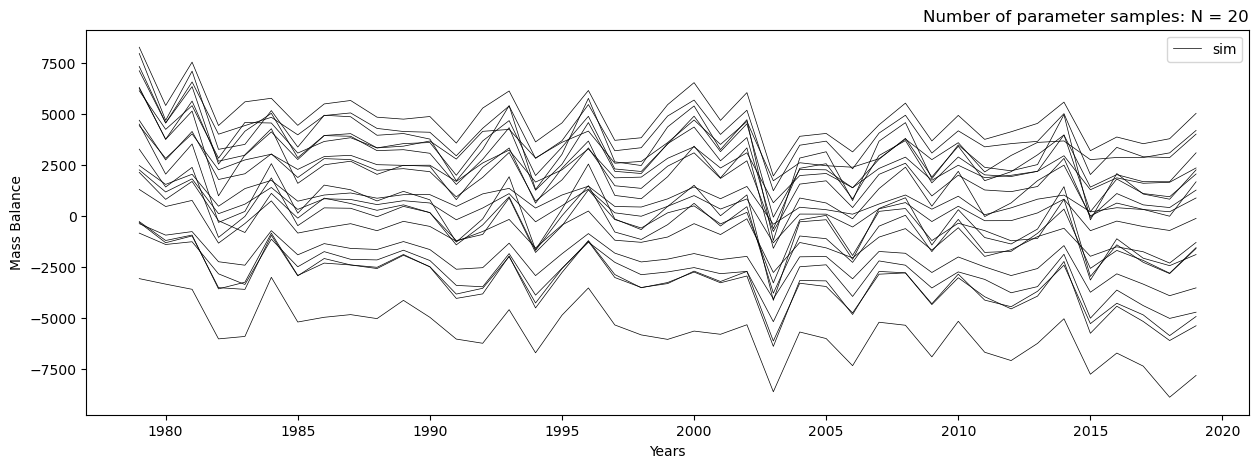

In [281]:
# Plot Monte Carlo (MC) simulations results for the Runoff and compare with data:
plt.figure(figsize=[15,5])
for j in range(mass_balance_sim.shape[0]):
    plt.plot(mbdf.index.values, mass_balance_sim[j], linewidth = 0.5, color = 'k')
# plt.plot(mbdf.index.values, np.transpose(mass_balance_sim), 'k', linewidth = 0.5)
plt.ylabel('Mass Balance'); plt.xlabel('Years')
plt.legend(['sim'])
plt.title("Number of parameter samples: N = %d" % N, loc='right')
plt.show()

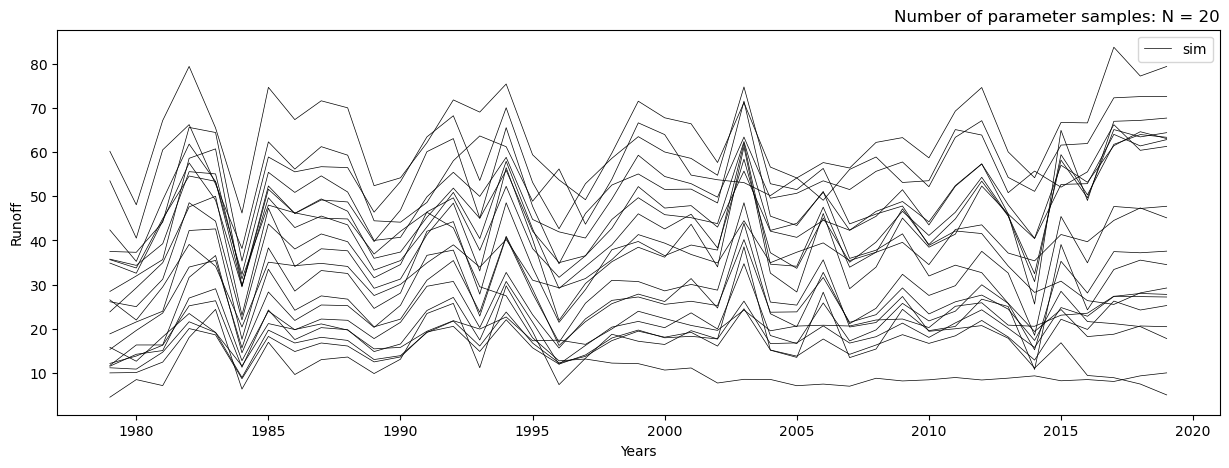

In [282]:
# Plot Monte Carlo (MC) simulations results for the Runoff and compare with data:
plt.figure(figsize=[15,5])
for j in range(runoff_sim.shape[0]):
    plt.plot(mbdf.index.values, runoff_sim[j], linewidth = 0.5, color ='k')
# plt.plot(mbdf.index.values, np.transpose(runoff_sim), 'k', linewidth = 0.5)
plt.ylabel('Runoff'); plt.xlabel('Years')
plt.legend(['sim'])
plt.title("Number of parameter samples: N = %d" % N, loc='right')
plt.show()

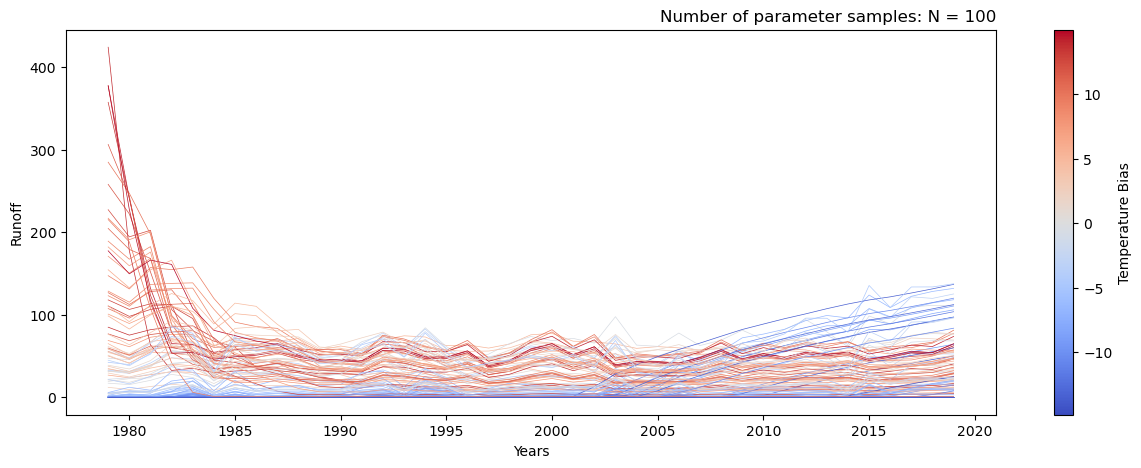

In [ ]:
# Also colour mapping (retrospectively) based on temp_bias values
import matplotlib.pyplot as plt
import numpy as np

temp_bias_index = 2  # Index of temp_bias in X

import matplotlib.pyplot as plt
import numpy as np

# Colormap and normalization
cmap = plt.cm.coolwarm
norm = plt.Normalize(vmin=X[:, temp_bias_index].min(), vmax=X[:, temp_bias_index].max())

fig, ax = plt.subplots(figsize=(15, 5))

# Plot each simulation with color based on temp_bias
for i in range(len(runoff_sim)):  # assuming QQ_runoff is (N, time)
    color = cmap(norm(X[i, temp_bias_index]))
    ax.plot(range(2003,2020), runoff_sim[i], linewidth=0.5, color=color)

ax.set_ylabel('Runoff')
ax.set_xlabel('Years')
ax.set_title(f"Number of parameter samples: N = {N}", loc='right')

# Add colorbar linked to the same colormap
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Temperature Bias')

plt.show()

In [151]:
YY_hydro = hydro_output_metric_calculator(runoff_sim)

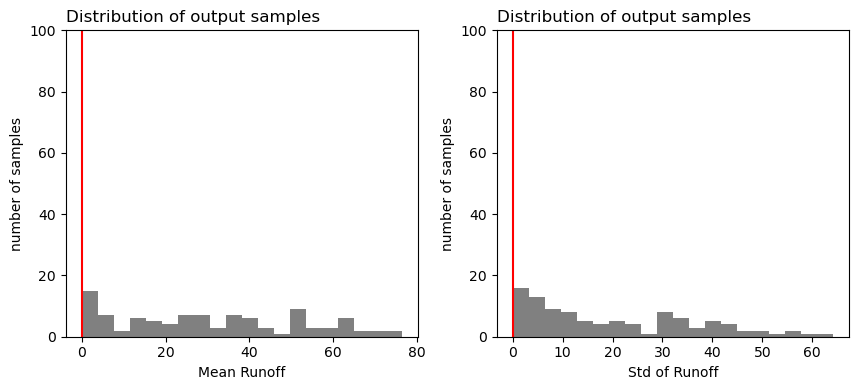

In [152]:
Y_lab_runoff_dist = ['Mean Runoff', 'Std of Runoff']

plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.title('Distribution of output samples', loc='left'), plt.hist(YY_hydro[:,0], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_lab_runoff_dist[0])

plt.subplot(1,3,2), plt.title('Distribution of output samples', loc='left'), plt.hist(YY_hydro[:,1], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_lab_runoff_dist[1])

plt.tight_layout()

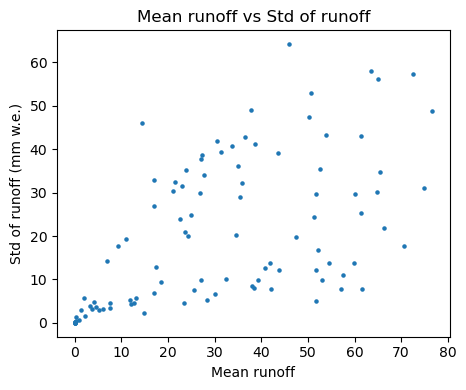

In [153]:
plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.scatter(YY_hydro[:,0], YY_hydro[:,1], s=5), plt.title('Mean runoff vs Std of runoff'), plt.xlabel('Mean runoff'), plt.ylabel('Std of runoff (mm w.e.)'),

plt.tight_layout()
plt.show()


In [154]:
Y_Labels = ['Mean Runoff', 'Std of Runoff']

def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        plt.plot(X[:, i], YY_hydro[:,j], '.', markerfacecolor="white", markeredgecolor="grey")        
        if i == 0:
            plt.ylabel(Y_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       
    plt.show()

interact(scatter_function,  metric = Y_Labels);

interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

In [155]:
temp_bias_index = 2

def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        # Use scatter with color mapped to temp_bias
        sc = plt.scatter(X[:, i], YY_hydro[:, j], c=X[:, temp_bias_index], cmap='coolwarm', edgecolors='grey')
        
        if i == 0:
            plt.ylabel(Y_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       

        # Add colorbar only once
        if i == M-1:
            cbar = plt.colorbar(sc)
            cbar.set_label('Temp Bias (°C)')
    plt.show()

interact(scatter_function, metric=Y_Labels);


interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

/home/chloe/micromamba/envs/oggm_env/lib/python3.11/site-packages/safepython/RSA_thres.py:303: UserWarning: Cannot find any output value below the threshold! Try increasing the threshold value
  warn('Cannot find any output value below the threshold! Try increasing the threshold value')
/home/chloe/micromamba/envs/oggm_env/lib/python3.11/site-packages/safepython/util.py:337: UserWarning: Statistics were computed using 47 bootstrap resamples instead of 50
  warn('Statistics were computed using ' + '%d' % (np.sum(idx))+


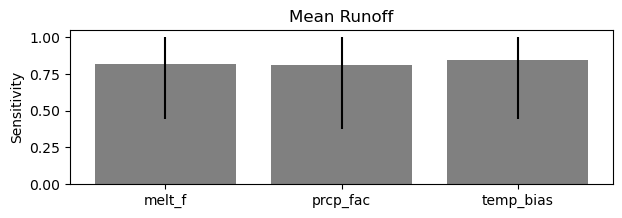

/home/chloe/micromamba/envs/oggm_env/lib/python3.11/site-packages/safepython/RSA_thres.py:303: UserWarning: Cannot find any output value below the threshold! Try increasing the threshold value
  warn('Cannot find any output value below the threshold! Try increasing the threshold value')
/home/chloe/micromamba/envs/oggm_env/lib/python3.11/site-packages/safepython/util.py:337: UserWarning: Statistics were computed using 48 bootstrap resamples instead of 50
  warn('Statistics were computed using ' + '%d' % (np.sum(idx))+


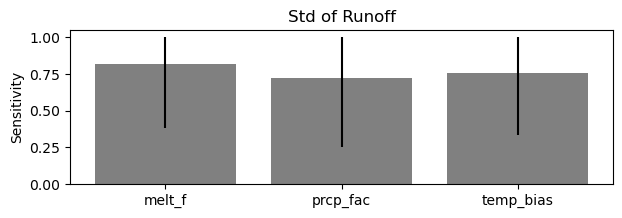

In [141]:
Nboot = 50 # Number of resamples used for bootstrapping
# TODO: Currently, I am not sure if we have observed hydro data for the runoff to set targets against?
# For now, we can just set some arbitrary target values to see the sensitivity indices
#  When we know what we are doing this will need to be updated - i.e. glacier we are investigating, questions we want to answer etc.
for i in range(2):
    if i==0:
        Y=YY_hydro[:,0]
        target=25
    if i==1:
        Y=YY_hydro[:,1]
        target=10

    # plot:
    plt.figure(figsize=[7,2])
    mvd, _, _, idx = RSA_tr.RSA_indices_thres(X, Y, target, Nboot=Nboot)
    mvd_m, mvd_lb, mvd_ub = aggregate_boot(mvd) # shape (M,)
    yerr=np.c_[mvd_m-mvd_lb,mvd_ub-mvd_m].T
    plt.bar(range(len(mvd_m)), mvd_m, color='grey',yerr=yerr)
    plt.title(Y_Labels[i], loc='center'), plt.xticks(range(len(mvd_m)), X_labels), plt.ylabel('Sensitivity')
    plt.show()

In [53]:
def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        # Use scatter with color mapped to temp_bias
        sc = plt.scatter(X[:, i], X[:, i-1], 
                         c=YY_hydro[:, j], cmap='coolwarm', edgecolors='grey')
        
        plt.ylabel(X_labels[i-1])    
        plt.xlabel(X_labels[i])      

        # Add colorbar only once
        if i == M-1:
            cbar = plt.colorbar(sc)
            cbar.set_label('Mean Runoff (Mt)')
    plt.show()

interact(scatter_function, metric=Y_Labels);


interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

## Sensitivity for the years 2000-2020

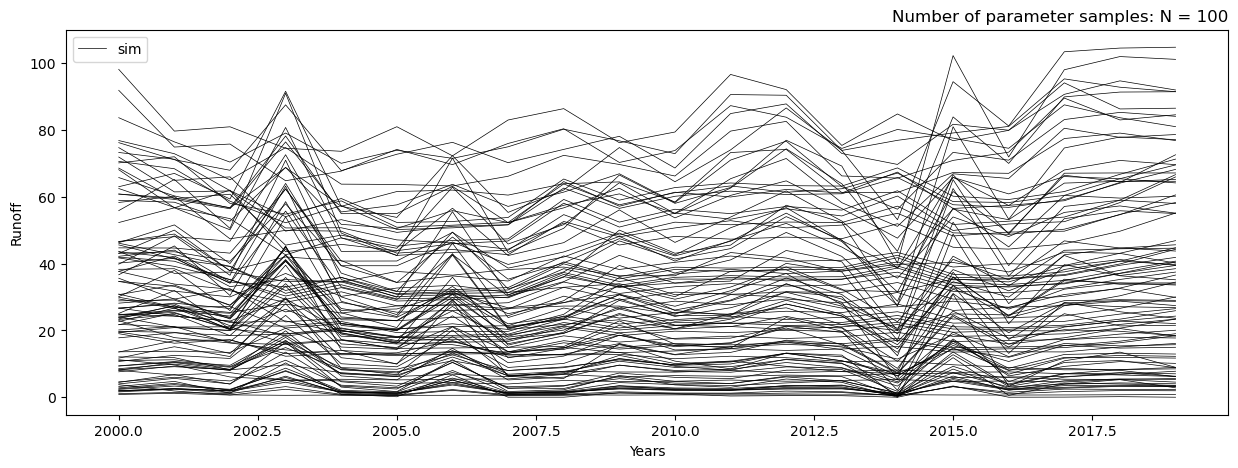

In [54]:
# # Plot Monte Carlo (MC) simulations results for the Runoff and compare with data:
# plt.figure(figsize=[15,5])
# plt.plot(mbdf.index.values, np.transpose(runoff), 'k', linewidth = 0.5)
# plt.ylabel('Runoff'); plt.xlabel('Years')
# plt.legend(['sim'])
# plt.title("Number of parameter samples: N = %d" % N, loc='right')
# plt.show()

runoff2000 = np.array([]).reshape(0,20)  # Reshape to have 20 years from 2000 to 2019

for run in runoff[0]:
    runoff2000 = np.vstack([runoff2000, run[21:41]])


# np.shape(runoff)
runoff2000

# Plot Monte Carlo (MC) simulations results for the Runoff and compare with data:
plt.figure(figsize=[15,5])
plt.plot(range(2000,2020), np.transpose(runoff2000),'k', linewidth = 0.5)
plt.ylabel('Runoff'); plt.xlabel('Years')
plt.legend(['sim'])
plt.title("Number of parameter samples: N = %d" % N, loc='right')
plt.show()



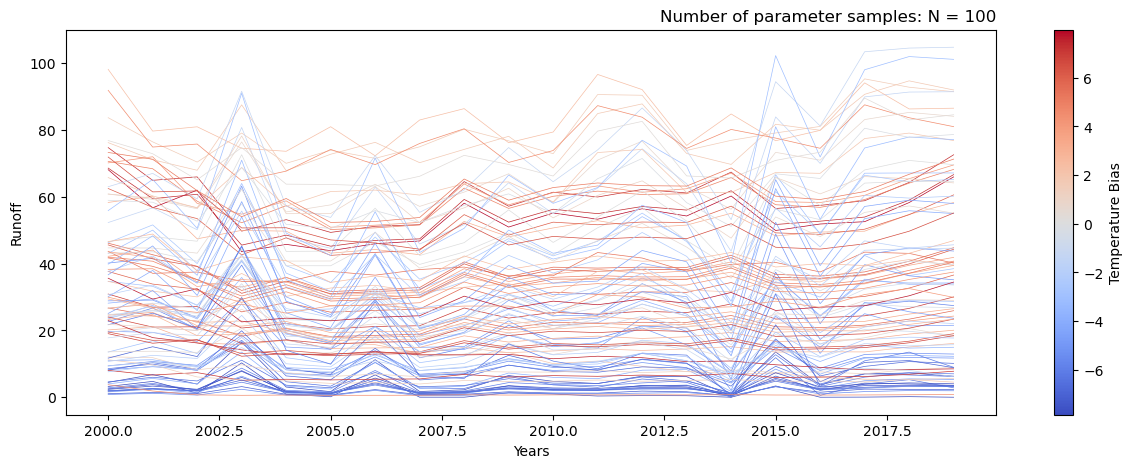

In [55]:
# Also colour mapping (retrospectively) based on temp_bias values
import matplotlib.pyplot as plt
import numpy as np

temp_bias_index = 2  # Index of temp_bias in X

import matplotlib.pyplot as plt
import numpy as np

# Colormap and normalization
cmap = plt.cm.coolwarm
norm = plt.Normalize(vmin=X[:, temp_bias_index].min(), vmax=X[:, temp_bias_index].max())

fig, ax = plt.subplots(figsize=(15, 5))

# Plot each simulation with color based on temp_bias
for i in range(np.shape(runoff2000)[0]):  # assuming QQ_runoff is (N, time)
    color = cmap(norm(X[i, temp_bias_index]))
    ax.plot(range(2000,2020), runoff2000[i, :], linewidth=0.5, color=color)

ax.set_ylabel('Runoff')
ax.set_xlabel('Years')
ax.set_title(f"Number of parameter samples: N = {N}", loc='right')

# Add colorbar linked to the same colormap
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Temperature Bias')

plt.show()

## Distribution of Model Outputs

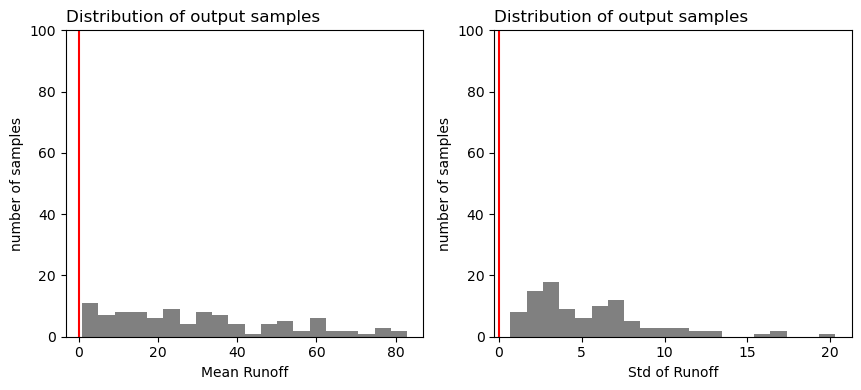

In [56]:
Y_lab_runoff_dist = ['Mean Runoff', 'Std of Runoff']

YY_hydro_2000 = hydro_output_metric_calculator(runoff2000)

plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.title('Distribution of output samples', loc='left'), plt.hist(YY_hydro_2000[:,0], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_lab_runoff_dist[0])

plt.subplot(1,3,2), plt.title('Distribution of output samples', loc='left'), plt.hist(YY_hydro_2000[:,1], bins=20, color='grey');
plt.axvline(x=0, color='r'), plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_lab_runoff_dist[1])

plt.tight_layout()

## Sensitivity Analysis

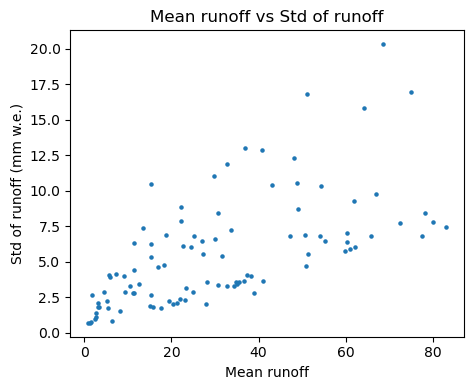

In [57]:
annual_mean_runoff = np.mean(runoff2000, axis=1) # Mean annual runoff for each sample
annual_std_runoff = np.std(runoff2000, axis=1) # Std annual runoff for each sample

plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.scatter(annual_mean_runoff, annual_std_runoff, s=5), plt.title('Mean runoff vs Std of runoff'), plt.xlabel('Mean runoff'), plt.ylabel('Std of runoff (mm w.e.)'),
plt.gca().locator_params(axis='x', nbins=6)

plt.tight_layout()
plt.show()


Here we are plotting the outputs of our runoff model and plotted the mean runoff values vs the standard deviation of the runoff values, this shows us the relationship between the two metrics. It can be seen here that for a lower mean runoff (under 40 (Mt) of runoff per our time period), in general there is a lower variation of runoff as well. 

Intuitively this makes sense considering that a lower average runoff would likely skew more towards lower runoff values varying throughout the year, or perhaps will have mostly low runoff with slighly higher runoff (to keep this variation low). However, once we surpass a runoff of 40 (Mt) per our time period, the realtionsip between the mean and std becomes abruptly uncorrelated. This is likely that at higher values, there are either a wider range of runoffs that could cause these higher mean runoffs, or that all runoff values could be sitting around this mean, resulting in a lower variation.

In [58]:
YY_hydro = np.nan * np.ones((N, 2))

for i, x in enumerate(runoff2000):
    YY_hydro[i,0] = np.mean(x)
    YY_hydro[i,1] = np.std(x)

Y_Labels = ['Mean Runoff', 'Std of Runoff']

def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        plt.plot(X[:, i], YY_hydro[:,j], '.', markerfacecolor="white", markeredgecolor="grey")        
        if i == 0:
            plt.ylabel(Y_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       
    plt.show()

interact(scatter_function,  metric = Y_Labels);

interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

### Now looking at scatter plots for a qualitative view of our sensitivity.

Firstly looking at the mean runoff over the course of a year:

- **The melt_f**: This appears to have a minimal relationship with the mean runoff, this appears almost randomly scattered, with a slight clustering towards a mean runoff of 0, but again this is evenly dispersed across all values of melt_f. Therefore, we can expect that the sensitivity analysis will show the melt_f having a very minimal effect on the mean runoff.

- **The prcp_fac**: This appears to have a slight relationship with the mean runoff, with a clustering of points in a positive linear relationship with the mean runoff. This intuitively is what we might expect, as the prcp_fac increases, this will increase the amount of precipitation on the glacier. If the temperature is above our threshold for solid precipitation, this will then cause the precipitation to contribute directly to the runoff. However, a large number of points is dispersed almost randomly with the prcp_fac, again showing us that perhaps this may not show as particulatly impactful for our sensitivity analysis in relation to the mean runoff. But perhaps slightly more so than that of melt_f?

- **The temp_bias**: This appears to have a very strong correlation with the mean_runoff. With a particularly tight correlation at large negative temperature biases. This makes sense, as this would ensure that the glacier atmospheric temperature is almost always below our threshold that would prevent both melt and liquid precipitation, leading to a very minimal runoff. As the temperature increases, and temp_bias exceeds 0 degrees Celcius, there is a very minimal relationship, with the points becoming more scattered. For our sensitivity analysis, from this, we can expect to see a large sensitivity for temp_bias. However, this is more likely due to the large range that we consider for temp_bias, which by default in the OGGM is [-15,15], if this was reduced to a smaller threshold then we can expect to see this sensitivity towards this parameter decreasing, and perhaps would expect prcp_fac to lead the sensitivity here.

Now looking at the standard deviation of the runoff over the course of a year:

- **The melt_f**: We can now see, that when considering the variation of the runoff over the course of the year, the melt_f now has a slight positive correlation. So that as the melt_f increases (the amount of melt that occurs in melt periods), the variation in the runoff also increases. This makes sense if we consider that when the temperature is above the melt temp threshold, there is very limited melting, however as the temperature increases and melt occurs, the quantity of melt (and therefore runoff) is controlled by the melt_f. Therefore this exaggerates the melting in the melting periods, which will contribute to the variation of the runoff. The melt factor fluctuates with temperatures that occur, some years

- **The prcp_f**: Now, there is very minimal correlation between the precipitation factor and the variation of the runoff across the year, this is likely due to the fact that the temperature bias is dominating here, and that the quantity of precipitation is not affecting the variation due to the fact that if the temperature is below the melting threshold then this does not contribute to the quantity of runoff. The prcp_fac does not dramatically change the rainfall from year to year, hence this will produce a minimal variation in our runoff. Changing the prcp_fac does not introduce new variability, only increases the baseline amount of rainfall. 

- **The temp_bias**: This parameter appears relatively similar to before, with a very tight correlation at negative temperature biases. This reduces the temperature, restricting the runoff and thus aligns with our expectations. As the temperature bias exceeds 0 and increases to a positive temperature bias, the correlation becomes a bit less tighly coupled, but there is still a clustering towards a positive correlation, this still affects the variation of runoff, as this raises the temperature uniformly, therefore potentially causing melt when there may not otherwise be. Again, the reason that this is so impactful on the standard deviation is likely due to the large range of temperature bias.

## The relationship of temp_bias with the other parameters.

After investigating the scatter plots and the tight correlations of temperature bias, we can assume this will be the dominating factor in our sensitivity analysis. We can investigate the relationship between the temp_bias and the other parameters on our plot with a colour mapping.

In [59]:
temp_bias_index = 2

def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        # Use scatter with color mapped to temp_bias
        sc = plt.scatter(X[:, i], YY_hydro[:, j], c=X[:, temp_bias_index], cmap='coolwarm', edgecolors='grey')
        
        if i == 0:
            plt.ylabel(Y_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       

        # Add colorbar only once
        if i == M-1:
            cbar = plt.colorbar(sc)
            cbar.set_label('Temp Bias (°C)')
    plt.show()

interact(scatter_function, metric=Y_Labels);


interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

As we would expect, we can see the clustering towards both the mean and std of the runoff being 0 can be attributed to the extreme negative values of the temperature bias as this restricts the precipitation factor or the melt factor from impacting the runoff amount here.



# Quantitative sensitivity: RSA with bootstrapping

Note: This is currently an abitrary threshold in which we can update if we obtain the desired values. I have put 25, this is the runoff standard deviation and mean value in Megatonnes per year. 

The RSA sensitivity analysis may be incorrect due to considering an arbitrary threshold, but this is an example of how the RSA can be used in this notebook with the OGGM runoff output.

If we obtain the correct values we can add this into our code easily.

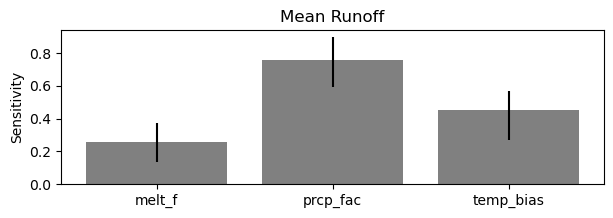

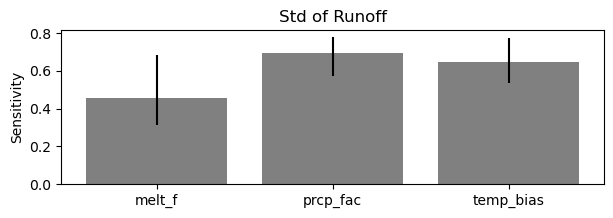

In [60]:
Nboot = 50 # Number of resamples used for bootstrapping
# TODO: Currently, I am not sure if we have observed hydro data for the runoff to set targets against?
# For now, we can just set some arbitrary target values to see the sensitivity indices
#  When we know what we are doing this will need to be updated - i.e. glacier we are investigating, questions we want to answer etc.
for i in range(2):
    if i==0:
        Y=YY_hydro[:,0]
        target=25
    if i==1:
        Y=YY_hydro[:,1]
        target=10

    # plot:
    plt.figure(figsize=[7,2])
    mvd, _, _, idx = RSA_tr.RSA_indices_thres(X, Y, target, Nboot=Nboot)
    mvd_m, mvd_lb, mvd_ub = aggregate_boot(mvd) # shape (M,)
    yerr=np.c_[mvd_m-mvd_lb,mvd_ub-mvd_m].T
    plt.bar(range(len(mvd_m)), mvd_m, color='grey',yerr=yerr)
    plt.title(Y_Labels[i], loc='center'), plt.xticks(range(len(mvd_m)), X_labels), plt.ylabel('Sensitivity')
    plt.show()

Now performing RSA with bootstrapping to quantify the sensitivity of our parameters to our output metrics and using bootstrapping to quantify the uncertainty here. 

As we expected, the sensitvity of the melt_f and prcp_fac paramaters is low and have a relatively large uncertainty compared to that of the temp_bias which is significantly the most impactful parameter with very minimal uncertainty.

It would be interesting here to reduce the range of the temperature bias to see if the sensitivity varies (we would expect the impact of the temp_bias to be reduced), and to try with an array of glaciers, mainly in High Mountain Asia. This glacier is within Austria, and observing an array of glacier could provide us with additional information about other glaciers.

## Investigating the relationship between parameters and the runoff

Here we will be plotting a combination of all the parameters we are investigating sensitivity for in a scatter plot, and colour-mapping the points by the values of the output metrics.

We have investigated sensitivity above, but this will allow us to investigate relationships of pairs of parameters in a bit more detail with the outputs of the runoff (both the mean of the runoff and the standard deviation of the runoff). 

In [304]:
def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        # Use scatter with color mapped to temp_bias
        sc = plt.scatter(X[:, i], X[:, i-1], 
                         c=YY_hydro[:, j], cmap='coolwarm', edgecolors='grey')
        
        plt.ylabel(X_labels[i-1])    
        plt.xlabel(X_labels[i])      

        # Add colorbar only once
        if i == M-1:
            cbar = plt.colorbar(sc)
            cbar.set_label('Mean Runoff (Mt)')
    plt.show()

interact(scatter_function, metric=Y_Labels);


interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

This shows the relationship between parameters in relation to the runoff output metrics, this is shown through plotting two parameter values against eachother in a scatter plot and colour-coded by the output metrics. We start by investigating by colour-mapping by magnitude of the Mean Runoff.
- We can see for each combination of parameters there appears to be a trend, in that the higher and lower mean runoff values tend to be cluster. However, for the temp_bias and prcp_fac there is a very strong and clear correlation, where the runoff has a very clear colour-gradient. This shows that the relationship between these two factors most strongly affects the mean runoff magnitude. The other two plots show that the prcp_fac dominates the effect by the melt_f, and similarly, showing the temp_bias dominates the effect by the melt_f.

Next, when colour-mapping by the standard deviation of the runoff. 
- We can see that for the melt_f vs the temp_bias there is a very strong relationship between them and the effect of the standard deviation of the runoff. Here both melt_f and the temp_bias appear to affect this output metric. Looking at the relationship between the melt_f and the prcp_f, there is a weak correlation, however it can be seen that the melt_f slightly dominates the effect on the standard deviation of the runoff. Finally, when looking at the relationship between the temp_bias and the prcp_fac, the temperature bias strongly dominates this relationship.


## Plotting the two together to have an easier comparison

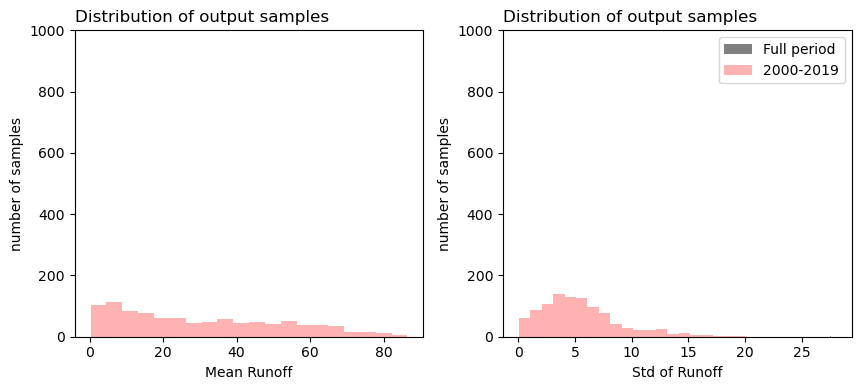

In [305]:
Y_lab_runoff_dist = ['Mean Runoff', 'Std of Runoff']

YY_hydro = np.nan * np.ones((N, 2))
YY_hydro2000 = np.nan * np.ones((N, 2))

for i, x in enumerate(runoff2000):
    YY_hydro2000[i,0] = np.mean(x)
    YY_hydro2000[i,1] = np.std(x)

for i, x in enumerate(runoff):
    YY_hydro[i,0] = np.mean(x)
    YY_hydro[i,1] = np.std(x)

plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.title('Distribution of output samples', loc='left'), plt.hist(YY_hydro[:,0], bins=20, color='grey');
plt.subplot(1,3,1), plt.title('Distribution of output samples', loc='left'), plt.hist(YY_hydro2000[:,0], bins=20, color='red', alpha=0.3);
plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_lab_runoff_dist[0])

plt.subplot(1,3,2), plt.title('Distribution of output samples', loc='left'), plt.hist(YY_hydro[:,1], bins=20, color='grey');
plt.subplot(1,3,2), plt.title('Distribution of output samples', loc='left'), plt.hist(YY_hydro2000[:,1], bins=20, color='red', alpha=0.3);
plt.ylim((0,N)), plt.ylabel('number of samples'), plt.xlabel(Y_lab_runoff_dist[1])

plt.legend(['Full period', '2000-2019'])

plt.tight_layout()

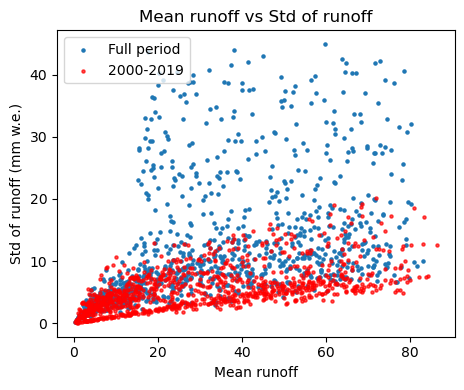

In [307]:
annual_mean_runoff_2000 = np.mean(runoff2000, axis=1) # Mean annual runoff for each sample
annual_std_runoff_2000 = np.std(runoff2000, axis=1) # Std annual runoff for each sample

annual_mean_runoff = np.mean(runoff[0], axis=1) # Mean annual runoff for each sample
annual_std_runoff = np.std(runoff[0], axis=1) # Std annual runoff for each sample

plt.figure(figsize=[13,4])
plt.subplot(1,3,1), plt.scatter(annual_mean_runoff, annual_std_runoff, s=5)
plt.subplot(1,3,1), plt.scatter(annual_mean_runoff_2000, annual_std_runoff_2000, s=5, color='red', alpha=0.7)
plt.title('Mean runoff vs Std of runoff'), plt.xlabel('Mean runoff'), plt.ylabel('Std of runoff (mm w.e.)'),
plt.gca().locator_params(axis='x', nbins=6)

plt.legend(['Full period', '2000-2019'])

plt.tight_layout()
plt.show()


In [309]:
YY_hydro = np.nan * np.ones((N, 2))
YY_hydro2000 = np.nan * np.ones((N, 2))

for i, x in enumerate(runoff2000):
    YY_hydro2000[i,0] = np.mean(x)
    YY_hydro2000[i,1] = np.std(x)

for i, x in enumerate(runoff[0]):
    YY_hydro[i,0] = np.mean(x)
    YY_hydro[i,1] = np.std(x)

Y_Labels = ['Mean Runoff', 'Std of Runoff']

def scatter_function(metric='Mean Runoff'):
    if metric == 'Mean Runoff':
        j = 0
    elif metric == 'Std of Runoff':
        j = 1  

    plt.figure(figsize=[18,3])
    for i in range(M):
        plt.subplot(1,M,i+1)
        plt.plot(X[:, i], YY_hydro[:,j], '.', markerfacecolor="white", markeredgecolor="grey")        
        plt.plot(X[:, i], YY_hydro2000[:,j], '.', markerfacecolor="white", markeredgecolor="red", alpha=0.5)   
        if i == 0:
            plt.ylabel(Y_Labels[j])
        else:
            plt.yticks([])       
        plt.xlabel(X_labels[i])       
    plt.show()

interact(scatter_function,  metric = Y_Labels);

interactive(children=(Dropdown(description='metric', options=('Mean Runoff', 'Std of Runoff'), value='Mean Run…

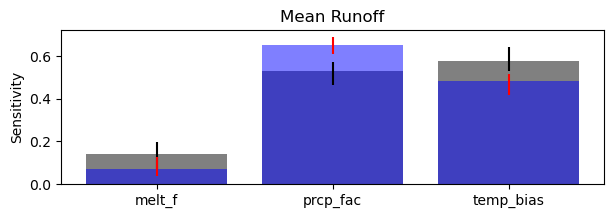

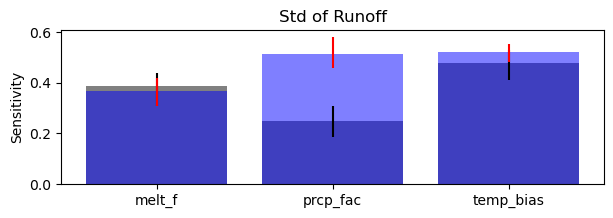

In [310]:
Nboot = 50 # Number of resamples used for bootstrapping
# TODO: Currently, I am not sure if we have observed hydro data for the runoff to set targets against?
# For now, we can just set some arbitrary target values to see the sensitivity indices
#  When we know what we are doing this will need to be updated - i.e. glacier we are investigating, questions we want to answer etc.
for i in range(2):
    if i==0:
        Y=YY_hydro[:,0]
        Y_2000=YY_hydro2000[:,0]
        target=25
    if i==1:
        Y=YY_hydro[:,1]
        Y_2000=YY_hydro2000[:,1]
        target=10

    # plot:
    plt.figure(figsize=[7,2])
    mvd, _, _, idx = RSA_tr.RSA_indices_thres(X, Y, target, Nboot=Nboot)
    mvd_2000, _, _, idx_2000 = RSA_tr.RSA_indices_thres(X, Y_2000, target, Nboot=Nboot)

    mvd_m, mvd_lb, mvd_ub = aggregate_boot(mvd) # shape (M,)
    mvd_m_2000, mvd_lb_2000, mvd_ub_2000 = aggregate_boot(mvd_2000) # shape (M,)

    yerr=np.c_[mvd_m-mvd_lb,mvd_ub-mvd_m].T
    yerr_2000=np.c_[mvd_m_2000-mvd_lb_2000,mvd_ub_2000-mvd_m_2000].T
    
    plt.bar(range(len(mvd_m)), mvd_m, color='grey',yerr=yerr)
    plt.bar(range(len(mvd_m_2000)), mvd_m_2000, color='blue',yerr=yerr_2000, alpha=0.5, ecolor='red')

    plt.title(Y_Labels[i], loc='center'), plt.xticks(range(len(mvd_m)), X_labels), plt.ylabel('Sensitivity')
    plt.show()

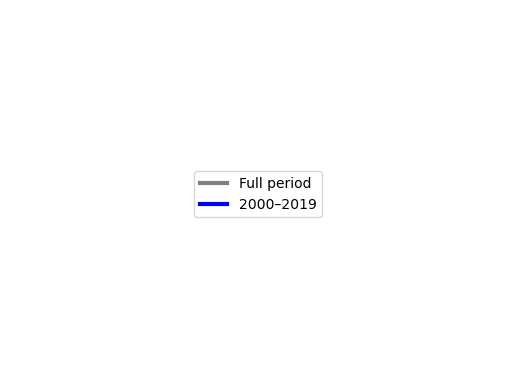

In [7]:

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Create proxy handles for the legend
handles = [
    Line2D([0], [0], color='grey', lw=3, label='Full period'),
    Line2D([0], [0], color='blue', lw=3, label='2000–2019')
]

fig, ax = plt.subplots()
ax.axis('off')  # hide axes
legend = ax.legend(handles=handles, loc='center', frameon=True)

plt.show()


## PAWN Sensitivity Analysis

Above, for the Global Sensitivity Analysis we have used only RSA with bootstapping as our sensitivity analysis technique. 

As we have discussed, RSA requires a target value to differentiate between "behavioural" and "non-behaviourable", which will reflect the sensitivities of our parameters. For runoff, as previously stated, we do not have an obvious metric to compare our data to. So we will investigate the use of another method in which we don't need this target value.

We will now move onto the PAWN technique to try another method of Sensitivity Analysis in the SAFE Toolbox that does not require a target value.